# Rail Corrugation
## Baseline Modelling

This notebook evaluates classical machine-learning models using the engineered rail corrugation features.

Models are evaluated using stratified cross-validation and Macro F1, matching the competition's primary evaluation metric.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

DATA_DIR = Path("..")

features = pd.read_csv(DATA_DIR / "rail_features.csv")

print(features.shape)
display(features.head())

(272, 30)


,side1_rms,side1_std,side1_mean_abs,side1_peak,side1_kurtosis,side1_skew,side2_rms,side2_std,side2_mean_abs,side2_peak,...,side2_power_0_100,side2_power_100_250,side2_power_250_500,side2_power_500_1000,side2_power_1000_2000,side2_power_2000_5000,rms_diff,rms_ratio,filename,label
0,0.196928,0.190938,0.143863,1.489258,3.425671,0.233946,0.178996,0.174950,0.129230,1.330566,...,0.000579,0.000313,0.000064,0.000007,0.000002,0.000004,0.017933,1.100184,Train1.csv,Normal
1,0.916845,0.915718,0.488347,19.201660,38.651499,1.865268,0.970224,0.969623,0.494209,26.440430,...,0.016843,0.006409,0.002893,0.002588,0.000261,0.000080,-0.053379,0.944982,Train2.csv,Side II
2,0.489453,0.487063,0.322309,10.131836,24.345089,0.395546,0.505371,0.503937,0.333544,8.630371,...,0.003987,0.001230,0.001336,0.002106,0.000155,0.000022,-0.015918,0.968503,Train3.csv,Normal
3,0.417142,0.414343,0.267033,6.518555,14.187037,0.413664,0.534819,0.533455,0.307011,13.818359,...,0.005535,0.001433,0.000591,0.000665,0.000047,0.000030,-0.117678,0.779967,Train4.csv,Normal
4,0.076755,0.059765,0.067120,0.378418,0.598831,0.605512,0.060023,0.046401,0.048291,0.366211,...,0.000011,0.000002,0.000015,0.000003,0.000002,0.000004,0.016732,1.278760,Train5.csv,Normal


In [2]:
X = features.drop(columns=["filename", "label"])
y = features["label"]

print(X.shape)
display(y.value_counts())

(272, 28)


label
Normal     234
Side II     24
Side I      14
Name: count, dtype: int64

In [3]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

## Logistic Regression

Logistic Regression provides a simple linear baseline.

Features are standardised because they have substantially different numerical scales.

In [5]:
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        class_weight="balanced",
        max_iter=2000
    )
)

In [6]:
scores = cross_val_score(
    logreg,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("Fold scores:", scores.round(3))
print("Mean Macro F1:", scores.mean().round(3))
print("Std:", scores.std().round(3))

Fold scores: [0.675 0.735 0.687 0.846 0.582]
Mean Macro F1: 0.705
Std: 0.086


In [7]:
rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=42
)

scores = cross_val_score(
    rf,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("Fold scores:", scores.round(3))
print("Mean Macro F1:", scores.mean().round(3))
print("Std:", scores.std().round(3))

Fold scores: [0.725 0.652 0.779 0.756 0.666]
Mean Macro F1: 0.716
Std: 0.05


In [8]:
hgb = HistGradientBoostingClassifier(
    max_iter=200,
    random_state=42
)

scores = cross_val_score(
    hgb,
    X,
    y,
    cv=cv,
    scoring="f1_macro"
)

print("Fold scores:", scores.round(3))
print("Mean Macro F1:", scores.mean().round(3))
print("Std:", scores.std().round(3))

Fold scores: [0.705 0.706 0.582 0.756 0.517]
Mean Macro F1: 0.653
Std: 0.089


## Model Comparison

The models are compared using the same five cross-validation folds and Macro F1 metric.

In [9]:
models = {
    "Logistic Regression": logreg,
    "Random Forest": rf,
    "Gradient Boosting": hgb
}

results = {}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring="f1_macro")
    results[name] = [scores.mean(), scores.std()]

results = pd.DataFrame(
    results,
    index=["Mean Macro F1", "Std"]
).T

display(results)

,Mean Macro F1,Std
Logistic Regression,0.705029,0.086461
Random Forest,0.715646,0.049533
Gradient Boosting,0.653289,0.089090


## Out-of-Fold Predictions

Cross-validation predictions allow us to examine per-class precision, recall and F1 while ensuring each prediction is made by a model that was not trained on that recording.

In [10]:
best_model = rf

pred = cross_val_predict(
    best_model,
    X,
    y,
    cv=cv
)

In [11]:
print(classification_report(y, pred, digits=3))

              precision    recall  f1-score   support

      Normal      0.973     0.936     0.954       234
      Side I      0.348     0.571     0.432        14
     Side II      0.750     0.750     0.750        24

    accuracy                          0.901       272
   macro avg      0.690     0.752     0.712       272
weighted avg      0.921     0.901     0.909       272



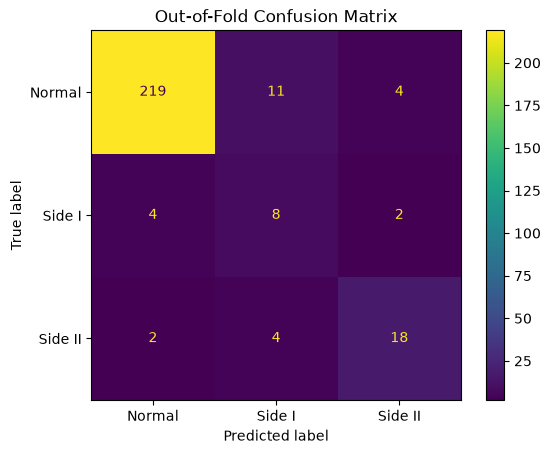

In [12]:
ConfusionMatrixDisplay.from_predictions(
    y,
    pred
)

plt.title("Out-of-Fold Confusion Matrix")
plt.show()

In [13]:
rf.fit(X, y)

importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

display(importance.head(15))

rms_diff                 0.121946
side1_power_250_500      0.085276
rms_ratio                0.085072
side1_power_500_1000     0.056575
side2_power_0_100        0.054264
side2_rms                0.051246
side1_peak               0.047604
side2_power_250_500      0.045863
side2_std                0.041628
side2_skew               0.033092
side2_power_1000_2000    0.030058
side1_std                0.029717
side1_rms                0.028921
side1_power_1000_2000    0.028679
side1_skew               0.028288
dtype: float64

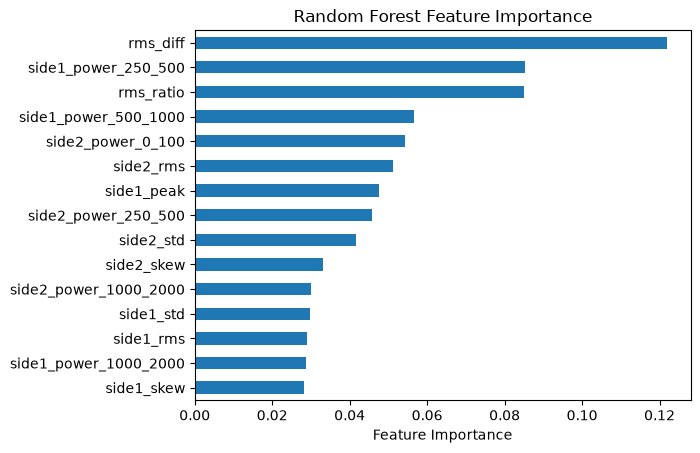

In [14]:
importance.head(15).sort_values().plot(kind="barh")

plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()